In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Experiment: MobileNetV2 + Triplet Loss - 204 Authors

Author identification experiment on handwritten documents using **Siamese Networks with Triplet Loss**.

**Objetive**: learn dn embedding space where patches from the same author cluster together and patches from different authors are pushed apart, enabling identification by similarity.

**Experiment setup**:
- Dataset: variant 4 (lines removed, grayscale)
- Authors: 204 (range 204)
- Architecture: MobileNetV2 fine-tuned + embedding head + triplet siamese network.

In [2]:
import os
import shutil
import datetime
import gc
import numpy as np
import tensorflow as tf
import random
from typing import Literal
import matplotlib.pyplot as plt
import pandas as pd
import math
from dataclasses import dataclass
from collections.abc import Iterable
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
)
import seaborn as sns
import cv2
import yaml

In [3]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs umap-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 118.4 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=5ba45192280950f53e815b472ec81fac8d13638fb3648ceccc50b1c1343526ba
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [ ]:
!pip install keras_hub keras

In [4]:
ModelType = Literal["pair", "triplet"]

@dataclass
class ModelConfig:
    type: ModelType

@dataclass
class DataConfig:
    authors_range: Iterable[int]
    original_shape: tuple[int, int, int]
    model_input_shape: tuple[int, int, int]

    def __post_init__(self):
        authors_array = np.asarray(list(self.authors_range))

        if authors_array.ndim != 1 or len(authors_array) == 0:
            raise ValueError("authors_range must be a non-empty 1D iterable")

        if len(np.unique(authors_array)) != len(authors_array):
            raise ValueError("authors_range contains duplicates")

        self.authors_range = authors_array
        self.authors = len(authors_array)


@dataclass
class TrainingConfig:
    epochs: int
    seed: int
    val_ratio: float

    def __post_init__(self):
        assert 0 < self.val_ratio < 1, "val_ratio must be between 0 and 1"


@dataclass
class BatchConfig:
    train: int
    validation: int
    test: int

    def __post_init__(self):
        assert self.train > 0
        assert self.validation > 0
        assert self.test > 0


@dataclass
class Config:
    project_path: str
    dataset: str
    model: ModelConfig
    data: DataConfig
    training: TrainingConfig
    batch: BatchConfig
    current_time: str

In [5]:
def load_config(path: str) -> Config:
  with open(path, "r") as f:
      cfg_dict = yaml.safe_load(f)

  authors_cfg = cfg_dict["data"]["authors_range"]

  return Config(
        project_path=cfg_dict["project_path"],
        dataset=cfg_dict["dataset"],
        model=ModelConfig(**cfg_dict["model"]),
        data=DataConfig(
            authors_range=range(authors_cfg["start"], authors_cfg["end"]),
            original_shape=tuple(cfg_dict["data"]["original_shape"]),
            model_input_shape=tuple(cfg_dict["data"]["model_input_shape"]),
        ),
        training=TrainingConfig(**cfg_dict["training"]),
        batch=BatchConfig(**cfg_dict["batch"]),
        current_time=datetime.datetime.now().strftime("%Y%m%d-%H%M%S"),
    )

In [6]:
config = load_config(path="drive/MyDrive/author-handwriting-recog/config/test_204_4.yaml")

In [7]:
def display_output(path: str):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    plt.figure(figsize=(w/100, h/100), dpi=100)
    plt.imshow(img, interpolation='nearest')
    plt.axis("off")
    plt.show()

In [8]:
def upload_source(source: str, source_dest: str):
    if os.path.exists(source_dest):
        shutil.rmtree(source_dest)

    shutil.copytree(source, source_dest)

In [9]:
def upload_file_to_source(source_file: str, dest_folder: str):
    os.makedirs(dest_folder, exist_ok=True)

    shutil.copy2(source_file, dest_folder)

In [10]:
upload_source(
    source=f"{config.project_path}/src",
    source_dest="./src"
)

In [11]:
upload_file_to_source(
    source_file=f"{config.project_path}/data/datasets/180_360_90/{config.dataset}.tar.gz",
    dest_folder=f"./dataset"
)

In [12]:
upload_file_to_source(
    source_file=f"{config.project_path}/data/datasets/experiments/mobilenet_204/mobilenet_siamese_model_204_20260331-113102.keras",
    dest_folder="./models"
)

In [85]:
upload_source(
    source=f"{config.project_path}/data/datasets/experiments/mobilenet_204/outputs",
    source_dest="./outputs"
)

In [14]:
random.seed(config.training.seed)
np.random.seed(config.training.seed)
tf.random.set_seed(config.training.seed)

In [15]:
from src.io import LoggerFactory
from src.datasets.loaders import SelectiveDataLoader
from src.generators import (
    AugmentationPipeline,
    AugmentationOps,
    AugmentImage,
    BaseGenerator,
    DataGenerator,
    TripletGenerator,
)

In [16]:
from src.models import (
    MobileNetV2Backbone,
    TripletLoss,
    EmbeddingNetwork,
    SiameseFactory
)
from src.training import (
    get_default_callbacks,
    ModelTrainerFactory,
    BaseMetricTrainer,
)
from src.evaluator import (
    TripletEvaluator,
    EmbeddingEvaluator,
    EmbeddingVisualizer,
)

In [17]:
from src.evaluator.embedding_utils import EmbeddingExtractor, UMAPReducer
from src.evaluator.embedding_strategy import (
    StrategyPipeline,
    OneNNStrategy,
    MeanStrategy,
    CentroidStrategy,
    TopKStrategy,
    PatchAggregator,
    VoteAggregator,
    ScoreAggregator,
)

In [18]:
logger = LoggerFactory.get_logger(
    "mobile_test_204_4",
    log_dir=f"./logs_{config.current_time}",
    file_prefix=f"mobile_triplet_{config.current_time}"
)

In [19]:
dataset_path = f"dataset/{config.dataset}.tar.gz"

In [20]:
!tar -xzf {dataset_path} -C ./

## Dataset

The dataset is stored in .zarr format with spatial separation between train and test:

```
dataset.zarr
├── non_test/   ← patches from the main writing area (train + val)
└── test/       ← patches from the test area, physically separated in the original image
```

`SelectiveDataLoader` selects a subset of authors and builds the three splits (train, val, test) guaranteeing that **no patch from the test area appears in train o val**.
This eliminates data leakage by spatial position.

In [21]:
loader = SelectiveDataLoader(
    dataset_path=f"./{config.dataset}.zarr",
    logger=logger,
    seed=config.training.seed
)

In [22]:
train, val, test = loader.build(
      authors=config.data.authors_range,
      validation_fraction=config.training.val_ratio,
  )

12:58:25 - mobile_test_204_4 - INFO - Total patches selected: 128891
12:58:25 - mobile_test_204_4 - INFO - Train: 96668 | Val: 32223 | Test: 8946
12:58:25 - mobile_test_204_4 - INFO - Avg non_test patches per author: 631.82 | Min: 142 | Max: 911
12:58:25 - mobile_test_204_4 - INFO - Avg test patches per author: 43.85 | Min: 22 | Max: 49
12:58:25 - mobile_test_204_4 - INFO - Image shape: (180, 360)
12:58:25 - mobile_test_204_4 - INFO - Zarr chunk shape: (64, 180, 360)


## Augmentation

Two distinct pipelines are used:

- **pipeline_train** - full augmentation: rotation, zoom, shift, noise, brightness, contrast
- **pipeline** - resize _ normalization only (no perturbations)

The training pipeline introduces artificial variability to improve generaliaztion. The validation/test pipeline is deterministic for reproducible evaluation.

> mobilenet_preprocess at the end is required - it normalizes pixel values to the range
> expected by MobileNetV2 (ImageNet statistics)

In [23]:
ops = AugmentationOps(
    rotation_range=6,
    width_shift_range=0.04,
    height_shift_range=0.05,
    horizontal_flip=False,
    resize_dim=config.data.model_input_shape[:2],
    brightness_delta=0.04,
    contrast_range=(0.95, 1.05),
    noise_stddev=0.01,
    zoom_range=(0.95, 1.05),
)
pipeline_train = AugmentationPipeline([
    ops.rotate,
    ops.zoom,
    ops.shift,
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.mobilenet_preprocess,
])
pipeline = AugmentationPipeline([
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.mobilenet_preprocess,
])
augment_train = AugmentImage(pipeline_train)
augment = AugmentImage(pipeline)

In [24]:
train_triplet = TripletGenerator(
    split=train,
    batch_size=config.batch.train,
    seed=config.training.seed,
    augment=augment_train
)
val_triplet = TripletGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_triplet = TripletGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [25]:
def display_generator_info(generator: BaseGenerator):
    config = generator.get_config()
    logger.info(f"Generator: {generator.__class__.__name__}")
    logger.info(f"Number of samples: {config['num_samples']}")
    logger.info(f"Batch size: {config['batch_size']}")
    logger.info(f"Steps per epoch: {config['steps_per_epoch']}")
    logger.info(f"Shape: {config['patch_shape']}")
    logger.info(f"Number of authors: {config['num_authors']}")

In [22]:
display_generator_info(train_triplet)

11:03:20 - mobile_test_204_4 - INFO - Generator: TripletGenerator
11:03:20 - mobile_test_204_4 - INFO - Number of samples: 96668
11:03:20 - mobile_test_204_4 - INFO - Batch size: 64
11:03:20 - mobile_test_204_4 - INFO - Steps per epoch: 1511
11:03:20 - mobile_test_204_4 - INFO - Shape: (180, 360)
11:03:20 - mobile_test_204_4 - INFO - Number of authors: 204


In [23]:
display_generator_info(val_triplet)

11:03:20 - mobile_test_204_4 - INFO - Generator: TripletGenerator
11:03:20 - mobile_test_204_4 - INFO - Number of samples: 32223
11:03:20 - mobile_test_204_4 - INFO - Batch size: 32
11:03:20 - mobile_test_204_4 - INFO - Steps per epoch: 1007
11:03:20 - mobile_test_204_4 - INFO - Shape: (180, 360)
11:03:20 - mobile_test_204_4 - INFO - Number of authors: 204


In [24]:
display_generator_info(test_triplet)

11:03:20 - mobile_test_204_4 - INFO - Generator: TripletGenerator
11:03:20 - mobile_test_204_4 - INFO - Number of samples: 8946
11:03:20 - mobile_test_204_4 - INFO - Batch size: 16
11:03:20 - mobile_test_204_4 - INFO - Steps per epoch: 560
11:03:20 - mobile_test_204_4 - INFO - Shape: (180, 360)
11:03:20 - mobile_test_204_4 - INFO - Number of authors: 204


## Model Construction

The architecture follows a chain of separated responsibilities:

```
MobileNetV2Backbone         → extracts visual features (pre-trained on ImageNet)
    ↓
EmbeddingNetwork            → projects features to an L2-normalized embedding space
    ↓
SiameseFactory              → builds the triplet siamese network (anchor, positive, negative)
    ↓
ModelTrainerFactory         → wraps the network in a trainer with training/eval logic
```

**`trainer.siamese_network`** — full triplet network, used during training.
**`trainer.embedding_model`** — backbone + embedding head, used to extract embeddings at evaluation time.
Both share the same weights in memory.

In [26]:
embedding_network = EmbeddingNetwork(
    backbone=MobileNetV2Backbone(freeze_base=False, fine_tune_at=100),
    input_shape=config.data.model_input_shape,
    num_authors=config.data.authors,
)

In [27]:
siamese_builder = SiameseFactory.create(
    model_type=config.model.type,
    embedding_network=embedding_network,
    input_shape=config.data.model_input_shape,
)

In [28]:
trainer = ModelTrainerFactory.create(
    siamese_builder=siamese_builder,
    train_generator=train_triplet,
    val_generator=val_triplet,
    model_name="mobilenet_triplet",
    model_type=config.model.type,
)

In [29]:
trainer.initialize_model()

/content/src/models/backbones/mobile_net.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


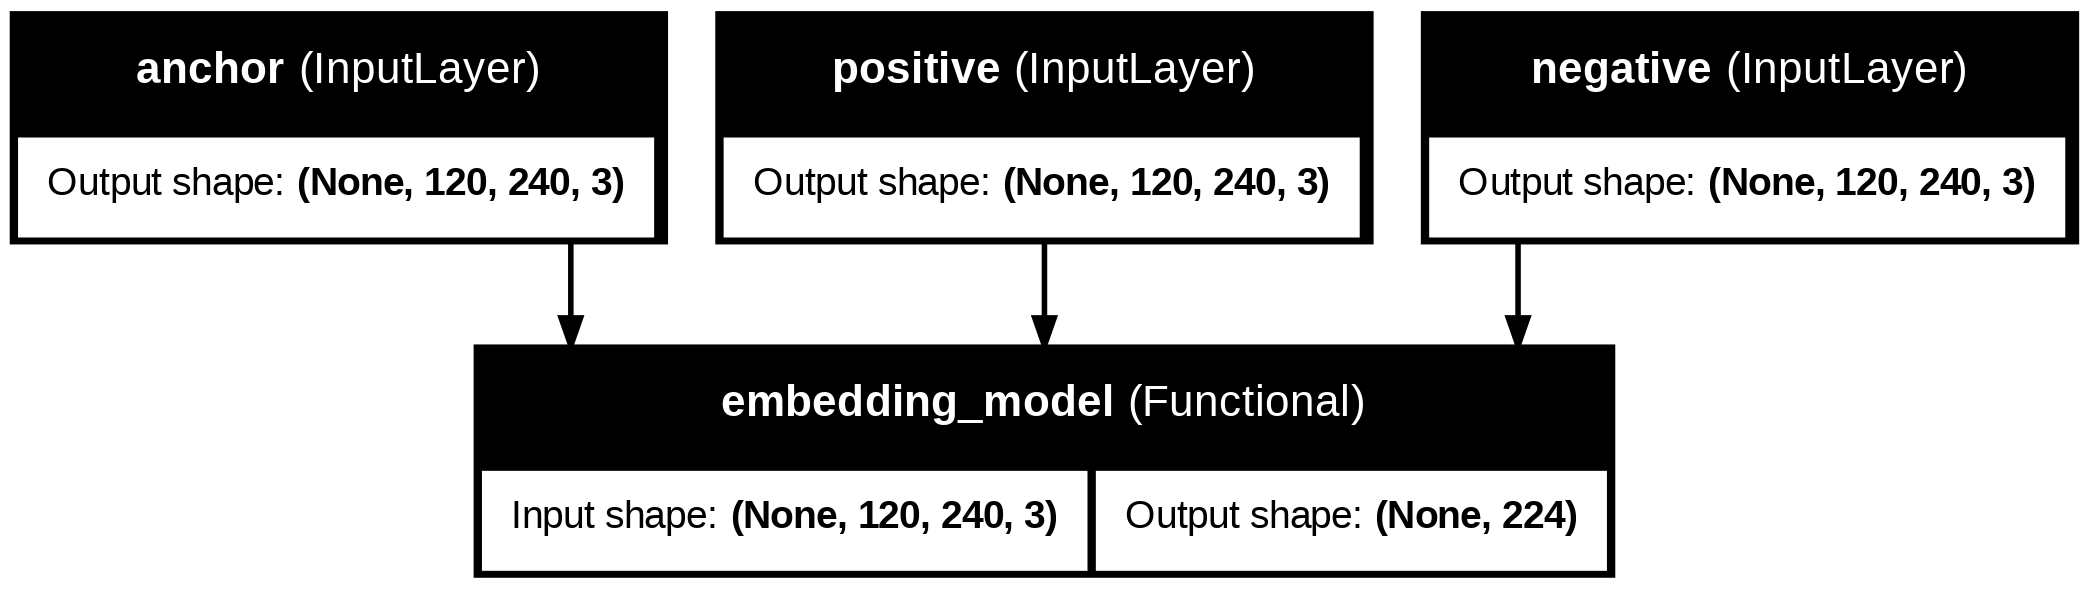

In [ ]:
tf.keras.utils.plot_model(
    trainer.siamese_network,
    show_shapes=True,
    show_layer_names=True,
)

In [ ]:
trainer.siamese_network.summary()

Model: "siamese_triplet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor (InputLayer) │ (None, 120, 240,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_model     │ (None, 224)       │  2,935,136 │ anchor[0][0],     │
│ (Functional)        │                   │            │ positive[0][0],   │
│                     │                   │            │ negative[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,935,136 (11.20 MB)

 Trainable params: 2,537,248 (9.68 MB)

 Non-trainable params: 397,888 (1.52 MB)

In [ ]:
trainer.embedding_model.summary()

Model: "embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 448)            │       573,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 448)            │         1,792 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 224)            │       100,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224)            │           896 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalization                │ (None, 224)            │             0 │
│ (L2Normalization)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,935,136 (11.20 MB)

 Trainable params: 2,537,248 (9.68 MB)

 Non-trainable params: 397,888 (1.52 MB)

## Compilation and Training

**TripletLoss** with margin=0.4:
minimizes max(d(a, p) - d(a, n) + margin, 0) where d is cosine distance.

**Monirored metrics**:
- ap_sim - average cosine similarity between anchor and positive (want: high)
- an_sim - average cosine similarity between anchor and negative (want: low)
- margin - difference ap_sim - an_sim (want: positive and increasin)
- triplet_acc - fraction of triplets where ap_sim > an_sim

**Callbacks**:
- EarlyStopping(patience=4) - stops training if vall_loss does not improve
- ReduceLROPlateau(patience=2) - reduces learning rate on plateau
- start_from_epoch=5 - early stopping is inactive during warm-up epochs

In [30]:
trainer.compile(
    loss=TripletLoss(margin=0.4),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=[
        tf.keras.metrics.Mean(name="ap_sim"),
        tf.keras.metrics.Mean(name="an_sim"),
        tf.keras.metrics.Mean(name="margin"),
        tf.keras.metrics.Mean(name="triplet_acc"),
    ],
)

In [ ]:
callbacks = get_default_callbacks(
    model_name="mobile_siamese_triplet",
    monitor="val_loss",
    mode="min",
    patience=4,
    start_from_epoch=5,
    reduce_lr_patience=2,
)

In [ ]:
history = trainer.train_model(
    epochs=config.training.epochs,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - an_sim: 9.3160e-06 - ap_sim: 0.0799 - loss: 0.3332 - margin: 0.0798 - triplet_acc: 0.6375
Epoch 1: val_loss improved from None to 0.23521, saving model to checkpoints/mobile_siamese_triplet/best.weights.h5

Epoch 1: finished saving model to checkpoints/mobile_siamese_triplet/best.weights.h5
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 606s 353ms/step - an_sim: -8.4526e-04 - ap_sim: 0.1520 - loss: 0.2886 - margin: 0.1529 - triplet_acc: 0.6910 - val_an_sim: 0.0821 - val_ap_sim: 0.3211 - val_loss: 0.2352 - val_margin: 0.2391 - val_triplet_acc: 0.7557 - learning_rate: 1.0000e-05
Epoch 2/50
1510/1511 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - an_sim: 0.0015 - ap_sim: 0.3072 - loss: 0.2192 - margin: 0.3057 - triplet_acc: 0.7659
Epoch 2: val_loss improved from 0.23521 to 0.19300, saving model to checkpoints/mobile_siamese_triplet/best.weights.h5

Epoch 2: finished saving model to checkpoints/mobile_siamese_triplet/best.weights.h5
1511/1511 ━━━━━━━━━━━━━━━

In [ ]:
def plot_keras_history(history: tf.keras.callbacks.History):

    df = pd.DataFrame(history.history)

    metrics = [col for col in df.columns if not col.startswith("val_")]

    n_metrics = len(metrics)
    n_cols = 2
    n_rows = math.ceil(n_metrics / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]

        ax.plot(df[metric], label=f"train_{metric}")

        val_metric = f"val_{metric}"
        if val_metric in df.columns:
            ax.plot(df[val_metric], label=f"val_{metric}")

        ax.set_title(metric)
        ax.set_xlabel("Epoch")
        ax.legend()

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

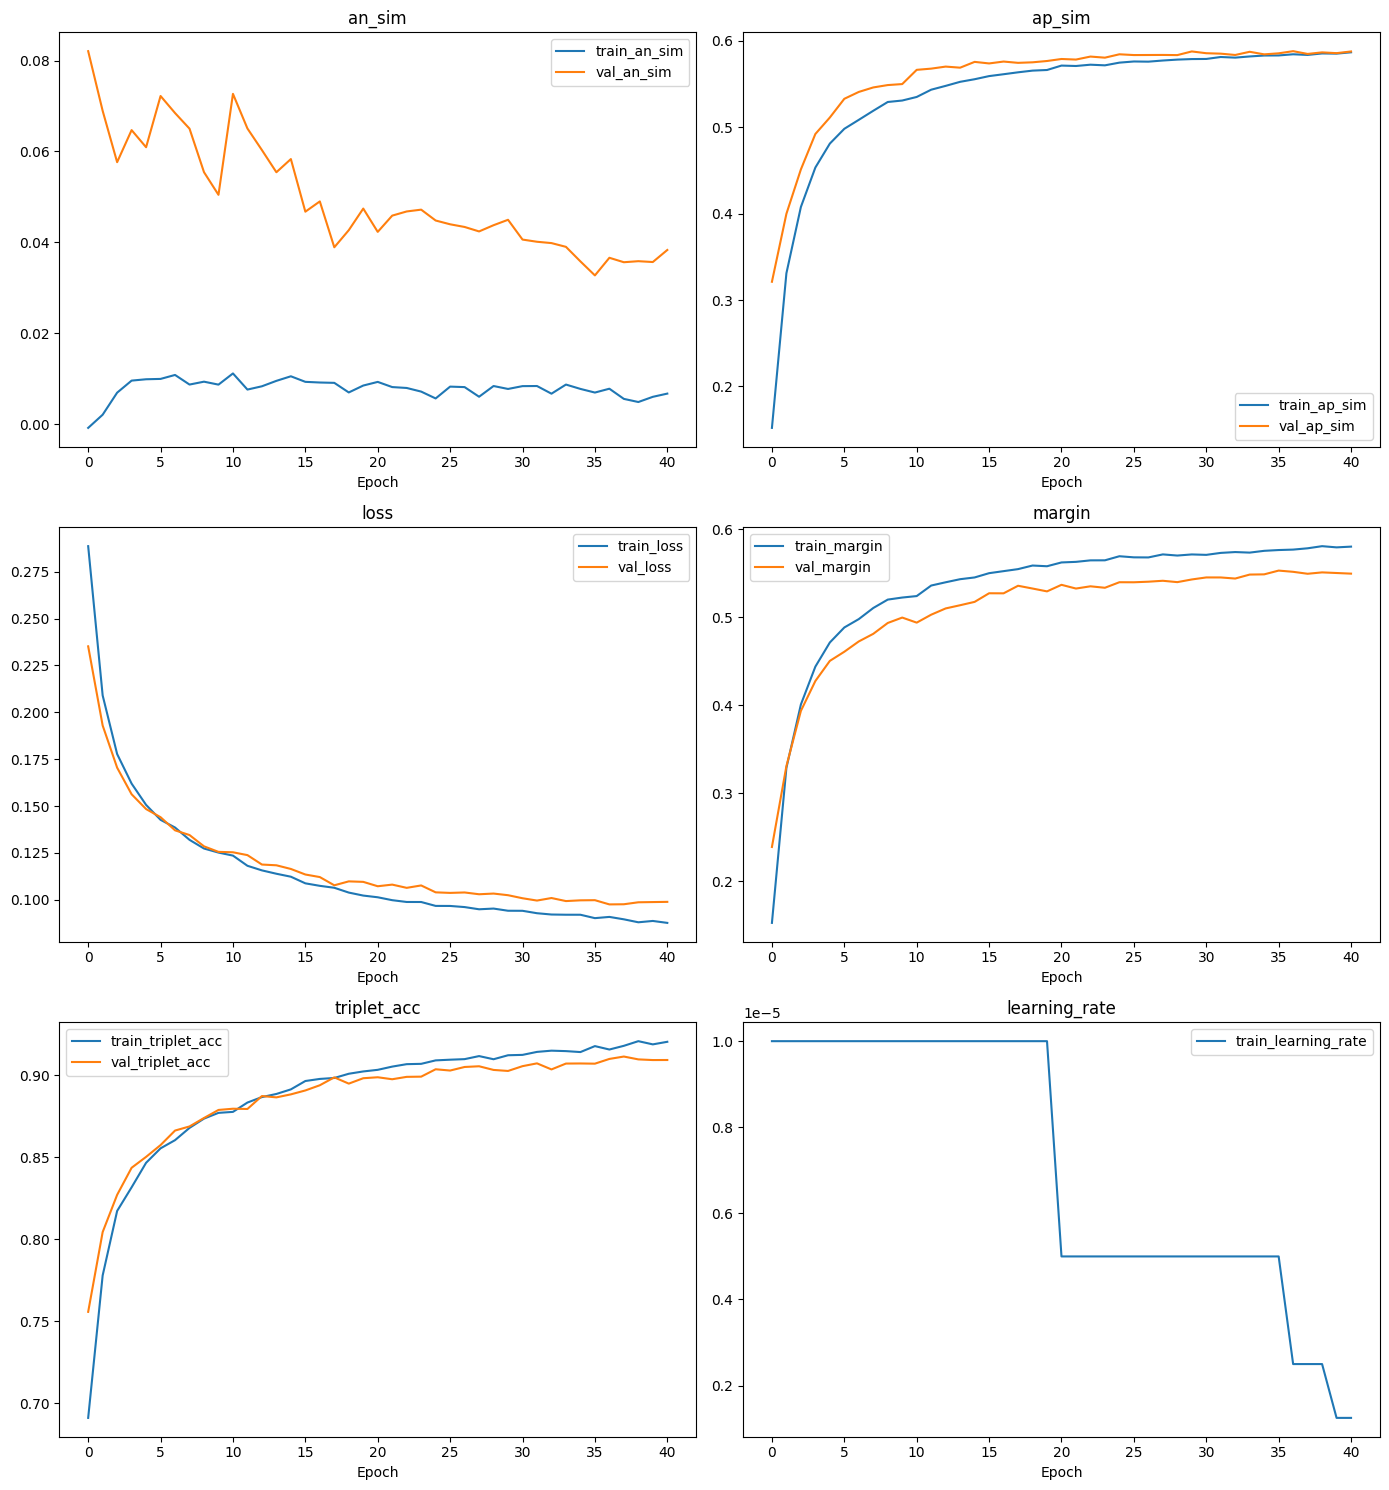

In [ ]:
plot_keras_history(history)

In [ ]:
def save_model(model: BaseMetricTrainer, path: str):
    model.siamese_network.save(f"{path}/mobilenet_siamese_model_204_{config.current_time}.keras")
    model.embedding_model.save(f"{path}/mobilenet_embedding_model_204_{config.current_time}.keras")

In [ ]:
save_model(model=trainer, path="./models")

In [ ]:
save_model(model=trainer, path=f"./{config.project_path}/data/datasets/experiments")

In [31]:
trainer.siamese_network.load_weights("./models/mobilenet_siamese_model_204_20260331-113102.keras")

In [32]:
metrics_val = trainer.evaluate_dict(val_triplet)
logger.info(f"\n{pd.DataFrame.from_dict(metrics_val, orient="index", columns=["value"])}")

1007/1007 ━━━━━━━━━━━━━━━━━━━━ 133s 106ms/step - an_sim: 0.0348 - ap_sim: 0.5881 - loss: 0.0975 - margin: 0.5533 - triplet_acc: 0.9092
13:01:25 - mobile_test_204_4 - INFO - 
                value
an_sim       0.034797
ap_sim       0.588117
loss         0.097529
margin       0.553320
triplet_acc  0.909195


In [33]:
metrics_test = trainer.evaluate_dict(test_triplet)
logger.info(f"\n{pd.DataFrame.from_dict(metrics_test, orient="index", columns=["value"])}")

560/560 ━━━━━━━━━━━━━━━━━━━━ 64s 78ms/step - an_sim: 0.0157 - ap_sim: 0.6373 - loss: 0.0758 - margin: 0.6216 - triplet_acc: 0.9324
13:03:15 - mobile_test_204_4 - INFO - 
                value
an_sim       0.015669
ap_sim       0.637275
loss         0.075761
margin       0.621606
triplet_acc  0.932372


In [34]:
def build_author_confusion_matrix(
    df: pd.DataFrame,
    true_col: str = "author_i",
    pred_col: str = "author_j"
) -> pd.DataFrame:
    authors = sorted(df[true_col].unique())

    cm = confusion_matrix(
        df[true_col],
        df[pred_col],
        labels=authors
    )

    cm_df = pd.DataFrame(
        cm,
        index=authors,
        columns=authors
    )

    return cm_df

In [35]:
def display_heatmap(
    df: pd.DataFrame,
    title: str = "Confusion Matrix",
    show_accuracy: bool = True,
) -> None:
    """
    Display confusion matrix heatmap with optional accuracy in title.
    """

    if show_accuracy:
        correct = np.trace(df.values)
        total = df.values.sum()
        acc = correct / total if total > 0 else 0.0

        title = f"{title} (Acc={acc:.3f})"

    plt.figure(figsize=(10, 8))
    sns.heatmap(df, cmap="Blues", linewidths=0.5)

    plt.xlabel("Predicted Author")
    plt.ylabel("True Author")
    plt.title(title)

    plt.show()

## Triplet Evaluation

`TripletEvaluator` evaluates the model in terms of **pairwise similarity**:

- Generates triplets (anchor, positive, negative) from the test set
- Computes cosine similarity between anchor-positive and anchor-negative pairs
- **AUC** — ability to discriminate similar pairs from dissimilar ones
- **Triplet accuracy** — % of triplets where `sim(a,p) > sim(a,n)`

This evaluation measures the quality of the similarity space,
independently of the author identification strategy.

In [36]:
triplet_evaluator = TripletEvaluator(
    siamese_network=trainer.siamese_network,
    logger=logger,
)

In [37]:
triplet_evaluator.data_generator = test_triplet
triplet_report = triplet_evaluator.evaluate()

13:03:15 - mobile_test_204_4 - INFO - === Triplet Evaluation Started ===
13:03:15 - mobile_test_204_4 - INFO - === Collecting triplet results ===
13:03:51 - mobile_test_204_4 - INFO - Total triplets collected: 560
13:03:52 - mobile_test_204_4 - INFO - [LOCAL] acc=0.9356 gap=0.6182 error=0.0644 auc=0.9349
13:03:52 - mobile_test_204_4 - INFO - === Computing global metrics ===
13:03:52 - mobile_test_204_4 - INFO - === Global metrics computed ===
13:03:52 - mobile_test_204_4 - INFO - === Triplet Evaluation Finished ===


In [38]:
logger.info(
    f"AUC: {triplet_report.local_metrics.auc:.2f}, "
    f"Accuracy: {triplet_report.local_metrics.triplet_accuracy:.2f}"
)

13:03:52 - mobile_test_204_4 - INFO - AUC: 0.93, Accuracy: 0.94


In [39]:
y_true = np.concatenate([
    np.ones(len(triplet_report.df_triplets)),
    np.zeros(len(triplet_report.df_triplets))
])
y_pred = np.concatenate([
    triplet_report.df_triplets["sim_ap"].values,
    triplet_report.df_triplets["sim_an"].values
])

### ROC Curve

The `ROC curve` evaluates the ability of the embedding space to distinguish between positive (same writer) and negative (different writer) pairs across all possible similarity thresholds.
The high `AUC` (≈0.94) indicates that the model learns a well-structured embedding space where genuine pairs are consistently assigned higher similarity scores than impostor pairs.

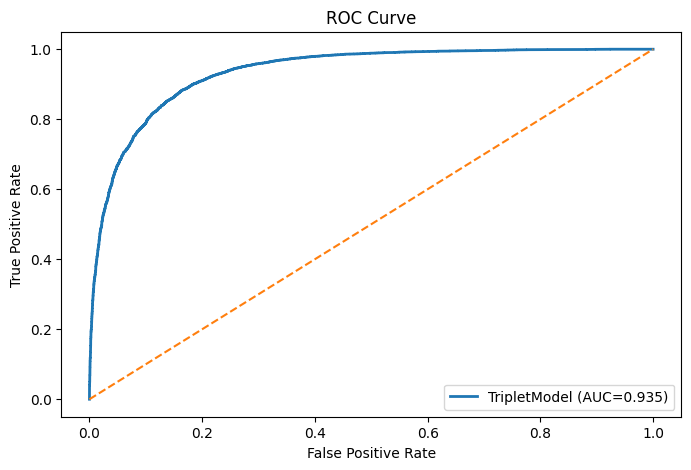

In [40]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
auc = roc_auc_score(y_true, y_pred)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, lw=2, label=f'TripletModel (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

plt.show()

In [41]:
# EER: is a point where FPR ≈ FNR
fnr = 1 - tpr
eer_threshold = thresholds[np.argmin(np.abs(fpr - fnr))]
eer = fpr[np.argmin(np.abs(fpr - fnr))]
logger.info(f"EER: {eer:.4f} at threshold {eer_threshold:.4f}")

13:03:58 - mobile_test_204_4 - INFO - EER: 0.1432 at threshold 0.3853


### Precision-Recall Curve

The `precision-recall` analysis highlights the trade-off between correctly identifying matching pairs (recall) and avoiding false matches (precision).
As expected, lower thresholds increase recall but introduce more false positives, while higher thresholds improve precision at the cost of missing true matches.
This curve is useful for selecting an operating threshold depending on the application requirements.

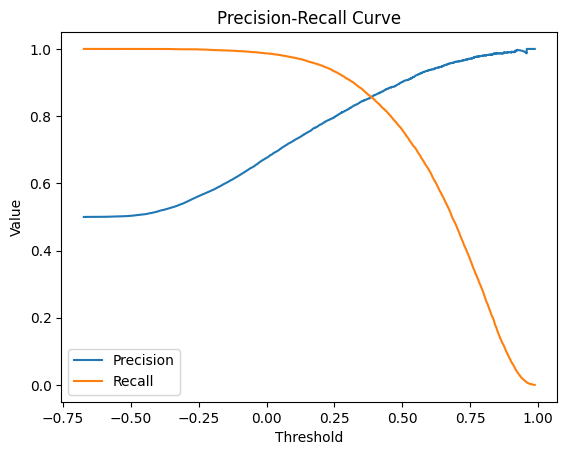

In [42]:
precision, recall, thresholds_pr = precision_recall_curve(y_true, y_pred)

plt.figure()
plt.plot(thresholds_pr, precision[:-1], label='Precision')
plt.plot(thresholds_pr, recall[:-1], label='Recall')

plt.xlabel('Threshold')
plt.ylabel('Value')
plt.title('Precision-Recall Curve')
plt.legend()

plt.show()

### Similarity Distribution

The similarity distribution plot shows the separation between positive pairs (same writer) and negative pairs (different writers) in the embedding space.
Positive pairs tend to have higher similarity values, while negative pairs are mostly concentrated in lower similarity regions.
This indicates that the model successfully learns a meaningful representation where samples from the same writer are closer in the feature space.

However, there is a noticeable overlap between the two distributions, particularly in the mid-range similarity values.
This overlap corresponds to ambiguous cases where the model struggles to distinguish between similar handwriting styles, leading to potential false positives and false negatives.

The degree of overlap explains why the model does not achieve perfect accuracy, despite the high AUC and triplet accuracy scores.
Reducing this overlap is key to further improving the model performance.

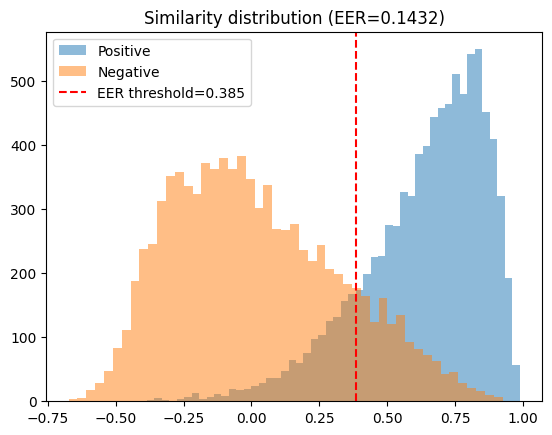

In [43]:
plt.hist(triplet_report.df_triplets["sim_ap"], bins=50, alpha=0.5, label="Positive")
plt.hist(triplet_report.df_triplets["sim_an"], bins=50, alpha=0.5, label="Negative")
plt.axvline(eer_threshold, linestyle='--', color='red', label=f"EER threshold={eer_threshold:.3f}")
plt.legend()
plt.title(f"Similarity distribution (EER={eer:.4f})")
plt.show()

### Confusion Matrix

The `confusion matrix` provides insight into which writers are more frequently confused by the model.
Strong diagonal values indicate correct identification, while off-diagonal entries reveal pairs of writers with similar handwriting characteristics.
This analysis helps identify systematic errors and potential limitations of the learned embedding space.

**Triplet-level Confusion Matrix**

The first confusion matrix is computed from individual triplet predictions.

Each decision is based on a local comparison between a positive and a negative sample.

This matrix reflects how often the model assigns the correct writer label in pairwise similarity decisions.

Due to the local nature of these comparisons, the matrix may contain noise and variability.

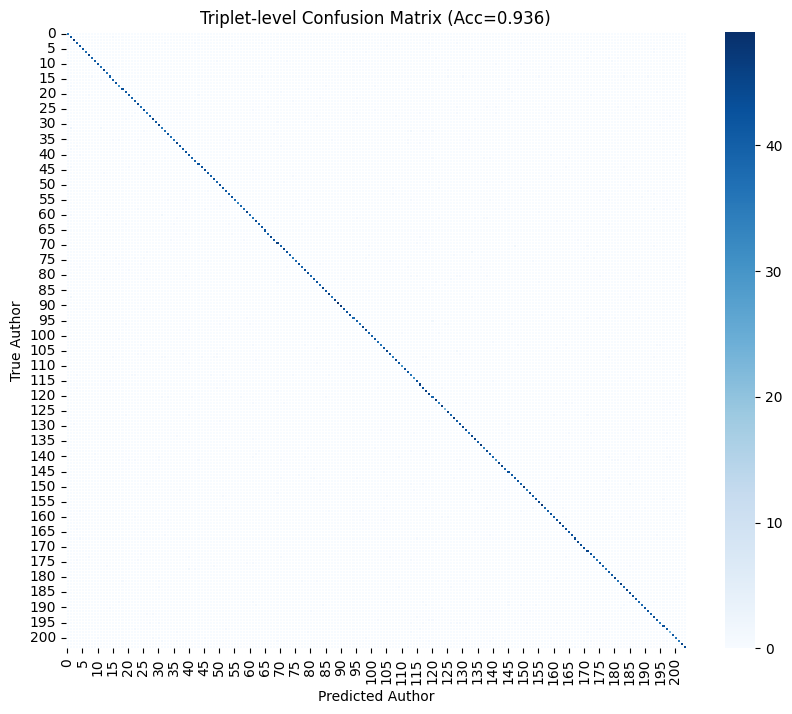

In [44]:
cm_df = build_author_confusion_matrix(
    triplet_report.df_triplets,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df, title="Triplet-level Confusion Matrix")

**Author-level Confusion Matrix**

The second confusion matrix is derived from aggregated metrics across triplets.

For each writer, the model selects the most representative prediction based on a scoring function combining accuracy and similarity gap.

This results in a more stable and global evaluation of the model’s ability to distinguish between different writers.

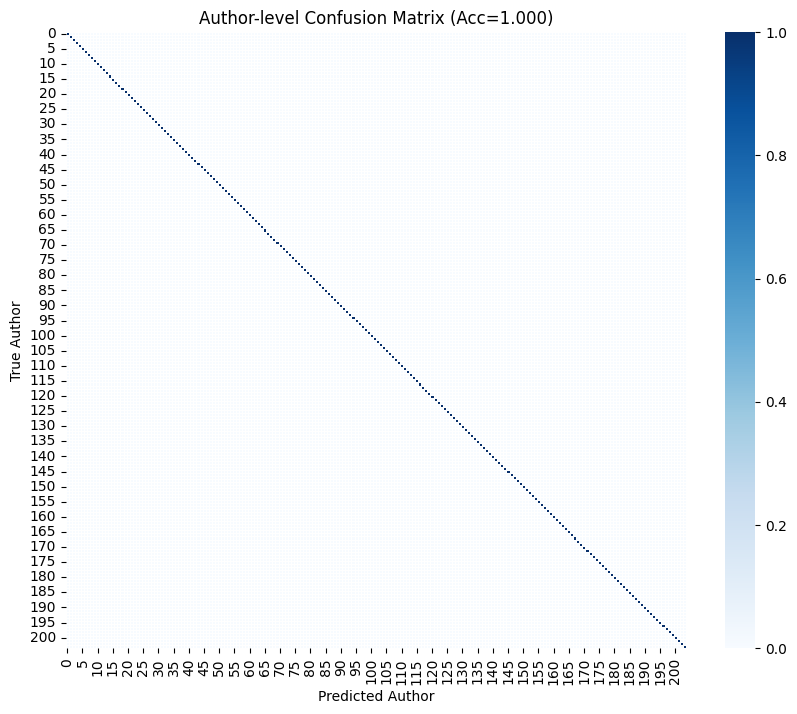

In [45]:
cm_df = build_author_confusion_matrix(
    triplet_report.global_metrics.df_by_score,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix")

**Comparison**

While the triplet-level matrix evaluates local decision quality, the author-level matrix reflects global identification performance.

Together, they provide a comprehensive understanding of both the embedding quality and the consistency of writer discrimination.

In [39]:
triplet_report.global_metrics.df_by_score

,anchor_label,pred_label,accuracy,mean_gap,count,gap_norm,score
0,0,0,1.0,0.884809,36,0.951518,0.951518
1,1,1,1.0,0.717423,42,0.860779,0.860779
2,2,2,1.0,0.857607,47,0.936772,0.936772
3,3,3,1.0,0.625855,44,0.811140,0.811140
4,4,4,1.0,0.583546,42,0.788205,0.788205
...,...,...,...,...,...,...,...
199,199,199,1.0,0.716198,39,0.860115,0.860115
200,200,200,1.0,0.490509,38,0.737770,0.737770
201,201,201,1.0,0.488231,37,0.736535,0.736535
202,202,202,1.0,0.881287,45,0.949609,0.949609


In [46]:
val_gen = DataGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_gen = DataGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [47]:
display_generator_info(val_gen)

13:04:48 - mobile_test_204_4 - INFO - Generator: DataGenerator
13:04:48 - mobile_test_204_4 - INFO - Number of samples: 32223
13:04:48 - mobile_test_204_4 - INFO - Batch size: 32
13:04:48 - mobile_test_204_4 - INFO - Steps per epoch: 1007
13:04:48 - mobile_test_204_4 - INFO - Shape: (180, 360)
13:04:48 - mobile_test_204_4 - INFO - Number of authors: 204


In [48]:
display_generator_info(test_gen)

13:04:50 - mobile_test_204_4 - INFO - Generator: DataGenerator
13:04:50 - mobile_test_204_4 - INFO - Number of samples: 8946
13:04:50 - mobile_test_204_4 - INFO - Batch size: 16
13:04:50 - mobile_test_204_4 - INFO - Steps per epoch: 560
13:04:50 - mobile_test_204_4 - INFO - Shape: (180, 360)
13:04:50 - mobile_test_204_4 - INFO - Number of authors: 204


## Embedding Evaluation

The main evaluation of the identification system.

**`EmbeddingExtractor`** uses `trainer.embedding_model` (not the full siamese network)
to extract one embedding per patch from the test set.

**Distance metrics:**
- `intra_distance` — average distance between patches from the **same** author
- `inter_distance` — average distance between patches from **different** authors
- A ratio `inter/intra >> 1` indicates good class separation in the embedding space

**Identification strategies:**
| Strategy | How it predicts the author of a patch |
|---|---|
| `1nn` | author of the nearest patch in the embedding space |
| `mean` | author whose mean embedding is most similar |
| `centroid` | author whose centroid (mean of train embeddings) is closest |
| `topk` | most frequent author among the K nearest neighbors |

**Aggregators — how predictions are aggregated at author level:**
| Aggregator | Logic |
|---|---|
| `patch` | accuracy per individual patch |
| `vote` | majority vote over all patches of the author |
| `score` | prediction by maximum average similarity |

> **The primary metric is `vote accuracy`.**
> Low patch accuracy (~60-80%) is expected and does not indicate model failure —
> an isolated patch can be ambiguous. Author identity emerges by aggregating
> evidence from multiple patches.

In [49]:
extractor = EmbeddingExtractor(
    model=trainer.embedding_model,
    logger=logger,
)

In [50]:
strategy_pipeline = StrategyPipeline(
    strategies=[
        OneNNStrategy(), MeanStrategy(), CentroidStrategy(), TopKStrategy(k=5),
    ],
    aggregators=[PatchAggregator(), VoteAggregator(), ScoreAggregator()],
    logger=logger,
)

In [51]:
emb_evaluator = EmbeddingEvaluator(
    extractor=extractor,
    pipeline=strategy_pipeline,
    logger=logger,
    seed=config.training.seed
)

In [36]:
val_gen_results = emb_evaluator.evaluate(val_gen)

13:49:52 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Starting evaluation
13:49:52 - mobile_test_204_4 - INFO - Extracting embeddings from the model
13:49:54 - mobile_test_204_4 - INFO - Processing 1007 batches to extract embeddings
13:52:39 - mobile_test_204_4 - INFO - Extracted embeddings for 32223 samples
13:52:39 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(32223, 224)
13:52:39 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances
13:52:39 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Reducing dimensionality with UMAP


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


13:53:25 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Evaluating strategies
13:53:25 - mobile_test_204_4 - INFO - Applying strategy pipeline with 4 strategies and 3 aggregators.
13:53:25 - mobile_test_204_4 - INFO - Applying strategy: 1nn
13:53:31 - mobile_test_204_4 - INFO - Applying aggregator: patch
13:53:31 - mobile_test_204_4 - INFO - Applying aggregator: vote
13:53:31 - mobile_test_204_4 - INFO - Applying aggregator: score
13:53:31 - mobile_test_204_4 - INFO - patch acc=0.3438Strategy '1nn' results: , vote acc=0.9902Strategy '1nn' results: , score acc=0.9902
13:53:31 - mobile_test_204_4 - INFO - Applying strategy: mean
13:57:29 - mobile_test_204_4 - INFO - Applying aggregator: patch
13:57:29 - mobile_test_204_4 - INFO - Applying aggregator: vote
13:57:29 - mobile_test_204_4 - INFO - Applying aggregator: score
13:57:29 - mobile_test_204_4 - INFO - patch acc=0.2821Strategy 'mean' results: , vote acc=0.5931Strategy 'mean' results: , score acc=0.5686
13:57:29 - mobile_test_204_4

In [37]:
logger.info(f"Intra distance: {val_gen_results.intra_distance}")
logger.info(f"Inter distance: {val_gen_results.inter_distance}")

for strategy_name, agg_results in val_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

14:04:07 - mobile_test_204_4 - INFO - Intra distance: 0.3647496998310089
14:04:07 - mobile_test_204_4 - INFO - Inter distance: 0.9593325257301331
14:04:07 - mobile_test_204_4 - INFO - Strategy: 1nn
14:04:07 - mobile_test_204_4 - INFO - Patch accuracy: 0.3438
14:04:07 - mobile_test_204_4 - INFO - Vote accuracy: 0.9902
14:04:07 - mobile_test_204_4 - INFO - Score accuracy: 0.9902
14:04:07 - mobile_test_204_4 - INFO - ----------------------------------------
14:04:07 - mobile_test_204_4 - INFO - Strategy: mean
14:04:07 - mobile_test_204_4 - INFO - Patch accuracy: 0.2821
14:04:07 - mobile_test_204_4 - INFO - Vote accuracy: 0.5931
14:04:07 - mobile_test_204_4 - INFO - Score accuracy: 0.5686
14:04:07 - mobile_test_204_4 - INFO - ----------------------------------------
14:04:07 - mobile_test_204_4 - INFO - Strategy: centroid
14:04:07 - mobile_test_204_4 - INFO - Patch accuracy: 0.3301
14:04:07 - mobile_test_204_4 - INFO - Vote accuracy: 0.9559
14:04:07 - mobile_test_204_4 - INFO - Score accur

In [52]:
test_gen_results = emb_evaluator.evaluate(
    data_generator=test_gen,
    reducer=UMAPReducer(n_components=3)
)

13:05:06 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Starting evaluation
13:05:06 - mobile_test_204_4 - INFO - Extracting embeddings from the model
13:05:06 - mobile_test_204_4 - INFO - Processing 560 batches to extract embeddings
13:06:35 - mobile_test_204_4 - INFO - Extracted embeddings for 8946 samples
13:06:35 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(8946, 224)
13:06:35 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances
13:06:35 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Reducing dimensionality with UMAP


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


13:07:11 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Evaluating strategies
13:07:11 - mobile_test_204_4 - INFO - Applying strategy pipeline with 4 strategies and 3 aggregators.
13:07:11 - mobile_test_204_4 - INFO - Applying strategy: 1nn
13:07:12 - mobile_test_204_4 - INFO - Applying aggregator: patch
13:07:12 - mobile_test_204_4 - INFO - Applying aggregator: vote
13:07:12 - mobile_test_204_4 - INFO - Applying aggregator: score
13:07:12 - mobile_test_204_4 - INFO - patch acc=0.6663Strategy '1nn' results: , vote acc=1.0000Strategy '1nn' results: , score acc=1.0000
13:07:12 - mobile_test_204_4 - INFO - Applying strategy: mean
13:07:43 - mobile_test_204_4 - INFO - Applying aggregator: patch
13:07:43 - mobile_test_204_4 - INFO - Applying aggregator: vote
13:07:43 - mobile_test_204_4 - INFO - Applying aggregator: score
13:07:43 - mobile_test_204_4 - INFO - patch acc=0.3662Strategy 'mean' results: , vote acc=0.5833Strategy 'mean' results: , score acc=0.5539
13:07:43 - mobile_test_204_4

In [53]:
logger.info(f"Intra distance: {test_gen_results.intra_distance}")
logger.info(f"Inter distance: {test_gen_results.inter_distance}")
logger.info(f"Inter/Intra ratio ≈ {test_gen_results.inter_distance/test_gen_results.intra_distance}")

for strategy_name, agg_results in test_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

13:08:39 - mobile_test_204_4 - INFO - Intra distance: 0.4172486662864685
13:08:39 - mobile_test_204_4 - INFO - Inter distance: 0.9766091704368591
13:08:39 - mobile_test_204_4 - INFO - Inter/Intra ratio ≈ 2.340592622756958
13:08:39 - mobile_test_204_4 - INFO - Strategy: 1nn
13:08:39 - mobile_test_204_4 - INFO - Patch accuracy: 0.6663
13:08:39 - mobile_test_204_4 - INFO - Vote accuracy: 1.0000
13:08:39 - mobile_test_204_4 - INFO - Score accuracy: 1.0000
13:08:39 - mobile_test_204_4 - INFO - ----------------------------------------
13:08:39 - mobile_test_204_4 - INFO - Strategy: mean
13:08:39 - mobile_test_204_4 - INFO - Patch accuracy: 0.3662
13:08:39 - mobile_test_204_4 - INFO - Vote accuracy: 0.5833
13:08:39 - mobile_test_204_4 - INFO - Score accuracy: 0.5539
13:08:39 - mobile_test_204_4 - INFO - ----------------------------------------
13:08:39 - mobile_test_204_4 - INFO - Strategy: centroid
13:08:39 - mobile_test_204_4 - INFO - Patch accuracy: 0.4399
13:08:39 - mobile_test_204_4 - IN

## Probabilistic Interpretation of Voting via Binomial Model

To understand why document-level accuracy reaches near-perfect values despite moderate patch-level accuracy, we can model the aggregation process using a binomial distribution.

### Setup

From the experiment:

- Average number of test patches per author: **n ≈ 44**
- Patch-level accuracy (1NN): **$p \approx 0.67$**

We model the number of correctly classified patches for a given author as:

$${X \sim Binomial \; (n, p)}$$

where:
- $(n)$ = number of patches per author ($\approx 44$)
- $(p)$ = probability a single patch is correctly classified ($\approx 0.67$)

---

### Majority Voting Condition

A correct document-level prediction via voting requires:

$$
X \ge \left\lceil \frac{n}{2} \right\rceil = 22
$$

---

### Expected Value and Variance

$$
\mu = n \cdot p = 44 \cdot 0.67 \approx 29
$$

$$
\sigma = \sqrt{np(1-p)} = \sqrt{44 \cdot 0.67 \cdot 0.33} \approx 3.12
$$

---

### Probability of Correct Majority

Using a normal approximation with continuity correction:

$$
P(X \ge 22) \approx P\left(Z \ge \frac{21.5 - 29}{3.12}\right)
$$

$$
Z \approx -2.4
$$

$$
P(X \ge 22) \approx 0.9918
$$

---

### Interpretation

- Although individual patches are only moderately accurate (`~67%`), the expected number of correct predictions per document is **`~29 out of 44`**, still well above the majority threshold (`22`).

- The probability of failing the majority vote is therefore **low (~0.8%)**, but not negligible.

- This implies that majority voting is **highly reliable but not theoretically perfect** under the independence assumption.

---

### Connection to Experimental Results

This explains the observed behavior:

- **Patch accuracy (~0.67)** → moderate classifier strength  
- **Vote accuracy (~1.0)** → near-perfect aggregation  

However, the theoretical estimate (~99.18%) does not fully account for the empirically observed perfect accuracy.

This discrepancy suggests that the binomial independence assumption is not fully representative of the real system behavior.

---

### Important Caveat

This analysis assumes independence between patches. In practice:

- Patches from the same document are **correlated**
- Errors are not independently distributed
- Certain patches are consistently easier or harder depending on the writer and local structure

As a result, the system does not behave like a simple ensemble of independent classifiers.

---

### Refined Interpretation

The binomial model provides a useful **lower-bound intuition**, but the observed robustness is better explained by the structure of the embedding space:

- Strong separation between classes (inter/intra ratio ≈ 2.3)
- Consistent local neighborhoods for each writer
- Errors concentrated in a small subset of ambiguous patches

Thus, voting works not only because $p > 0.5$, but because:

> Most patches for a given document are embedded closer to the correct class than to any competing class.

This leads to highly consistent nearest-neighbor decisions across patches.

---

### Conclusion

> The binomial model shows that majority voting is already highly reliable when $p > 0.5$, even with moderate accuracy (~67%). However, it underestimates the true system performance because it ignores the geometric structure of the embedding space and the non-independent nature of the samples.

> In practice, near-perfect document-level accuracy arises from a combination of moderate per-patch accuracy and strong embedding separability, rather than from aggregation alone.

## Visualization and Error Analysis

`EmbeddingVisualizer` allows exploring the embedding space and model errors.

- `plot_embeddings()` — UMAP projection of the embedding space, colored by author
- `plot_centroids()` — centroid of each author in UMAP space
- `log_error_samples()` — patches misclassified at patch level
- `plot_confusion()` — confusion matrix by `aggregators`

> Patch-level errors are informative: they reveal which authors have similar styles or nearby embeddings in the learned space.

> If vote accuracy is high despite patch errors, the model is working correctly — individual patch ambiguity is resolved by majority aggregation.

In [54]:
viz = EmbeddingVisualizer(
    report=test_gen_results,
    logger=logger,
    split=test,
)

In [55]:
viz.set_strategy("1nn")

In [56]:
viz.plot_embeddings()

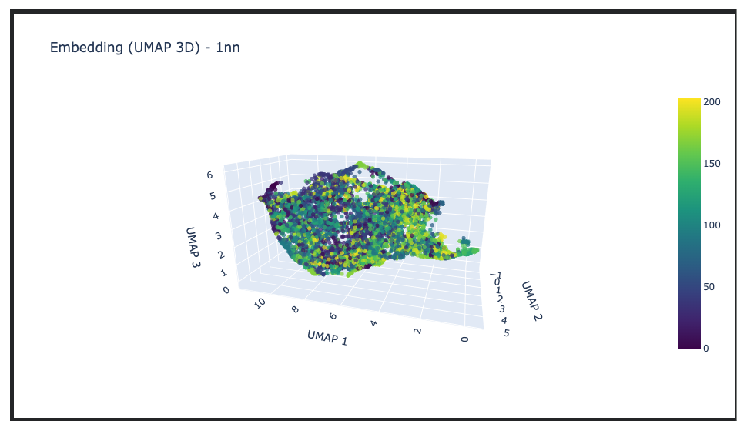

In [86]:
display_output(path="./outputs/embeddings.png")

In [57]:
viz.log_samples(n=20)

13:26:58 - mobile_test_204_4 - INFO - Showing 20 samples:
13:26:58 - mobile_test_204_4 - INFO - [idx=4334] lines2_Page_34 → lines2_Page_34
13:26:58 - mobile_test_204_4 - INFO - [idx=4309] lines2_Page_33 → lines3_Page_52
13:26:58 - mobile_test_204_4 - INFO - [idx=7781] lines3_Page_46 → lines3_Page_46
13:26:58 - mobile_test_204_4 - INFO - [idx=2713] lines1_Page_65 → lines1_Page_65
13:26:58 - mobile_test_204_4 - INFO - [idx=2334] lines1_Page_56 → lines1_Page_56
13:26:58 - mobile_test_204_4 - INFO - [idx=5447] lines2_Page_60 → lines1_Page_46
13:26:58 - mobile_test_204_4 - INFO - [idx=8416] lines3_Page_60 → lines1_Page_15
13:26:58 - mobile_test_204_4 - INFO - [idx=7487] lines3_Page_37 → lines3_Page_37
13:26:58 - mobile_test_204_4 - INFO - [idx=6485] lines3_Page_15 → lines3_Page_15
13:26:58 - mobile_test_204_4 - INFO - [idx=1861] lines1_Page_45 → lines1_Page_45
13:26:58 - mobile_test_204_4 - INFO - [idx=469] lines1_Page_11 → lines1_Page_11
13:26:58 - mobile_test_204_4 - INFO - [idx=2470] lin

In [58]:
viz.plot_centroids()

13:27:00 - mobile_test_204_4 - INFO - Estimated DBSCAN eps=0.7377 | clusters=32


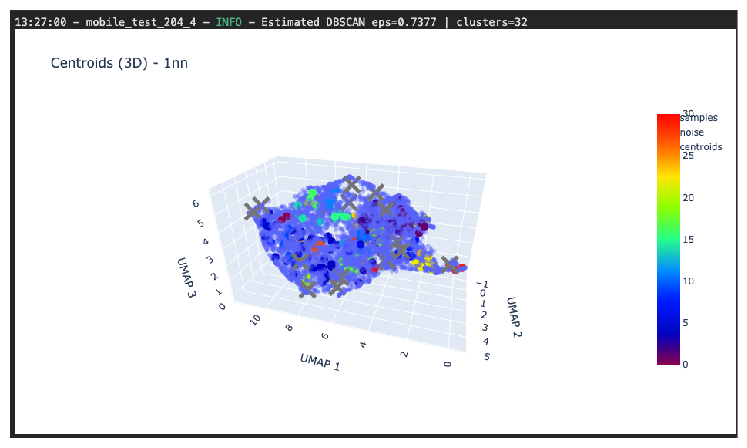

In [87]:
display_output(path="./outputs/embeddings_centroids.png")

In [59]:
one_nn = test_gen_results.strategy_results['1nn']

**Patch-level Confusion Matrix**

The patch-level confusion matrix evaluates the model’s predictions on individual image patches.

Since each patch contains only partial handwriting information, predictions at this level are inherently noisy.

This results in noticeable confusion between authors with similar local stroke patterns.

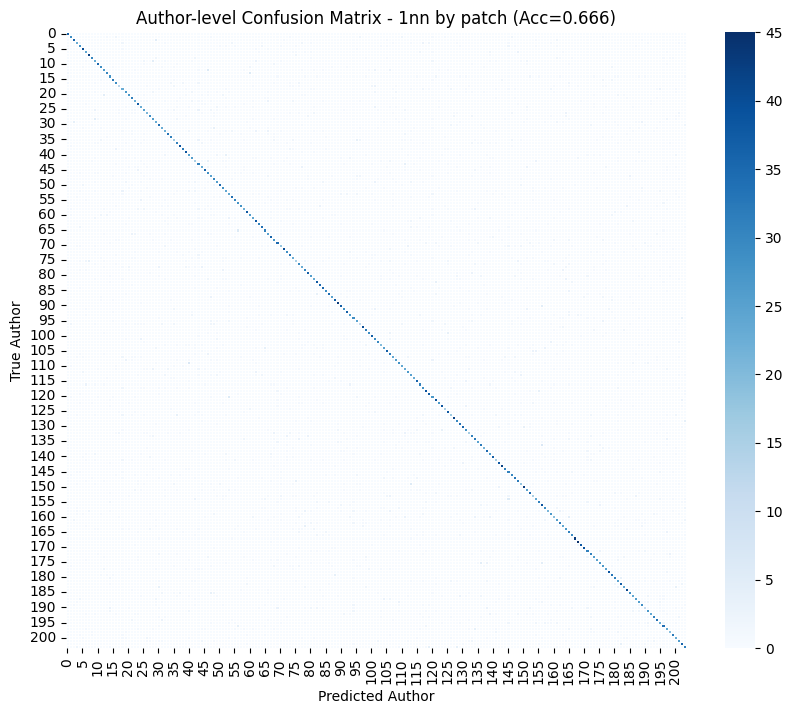

In [60]:
onenn_by_patch = one_nn['patch']
cm_df = build_author_confusion_matrix(
    onenn_by_patch.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix - 1nn by patch")

**Vote-level Confusion Matrix**

The vote-level confusion matrix represents the final classification performance after aggregating predictions across multiple patches.

By combining information from several patches, the model achieves more robust and stable predictions, significantly reducing classification errors.

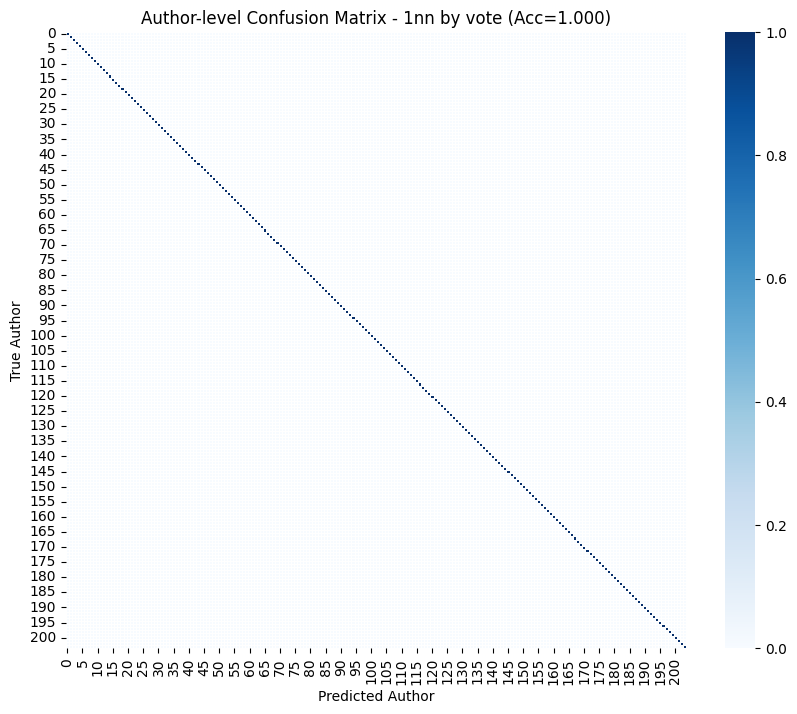

In [61]:
onenn_by_vote = one_nn['vote']
cm_df = build_author_confusion_matrix(
    onenn_by_vote.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix - 1nn by vote")

**Comparison**

The comparison between patch-level and vote-level confusion matrices highlights the importance of aggregation.

While individual patch predictions may be ambiguous, the aggregation process effectively resolves these ambiguities, leading to improved author identification performance.

In [62]:
viz.set_strategy("topk")

In [63]:
viz.log_samples(n=20)

13:28:54 - mobile_test_204_4 - INFO - Showing 20 samples:
13:28:54 - mobile_test_204_4 - INFO - [idx=283] lines1_Page_07 → lines3_Page_06
13:28:54 - mobile_test_204_4 - INFO - [idx=8672] lines4_Page_01 → lines3_Page_32
13:28:54 - mobile_test_204_4 - INFO - [idx=581] lines1_Page_14 → lines1_Page_14
13:28:54 - mobile_test_204_4 - INFO - [idx=6063] lines3_Page_05 → lines4_Page_07
13:28:54 - mobile_test_204_4 - INFO - [idx=7854] lines3_Page_48 → lines3_Page_48
13:28:54 - mobile_test_204_4 - INFO - [idx=2661] lines1_Page_64 → lines1_Page_64
13:28:54 - mobile_test_204_4 - INFO - [idx=8113] lines3_Page_53 → lines2_Page_18
13:28:54 - mobile_test_204_4 - INFO - [idx=7394] lines3_Page_35 → lines3_Page_35
13:28:54 - mobile_test_204_4 - INFO - [idx=3386] lines2_Page_12 → lines1_Page_42
13:28:54 - mobile_test_204_4 - INFO - [idx=8358] lines3_Page_59 → lines1_Page_15
13:28:54 - mobile_test_204_4 - INFO - [idx=143] lines1_Page_04 → lines4_Page_07
13:28:54 - mobile_test_204_4 - INFO - [idx=3530] lines

In [64]:
topk = test_gen_results.strategy_results['topk']

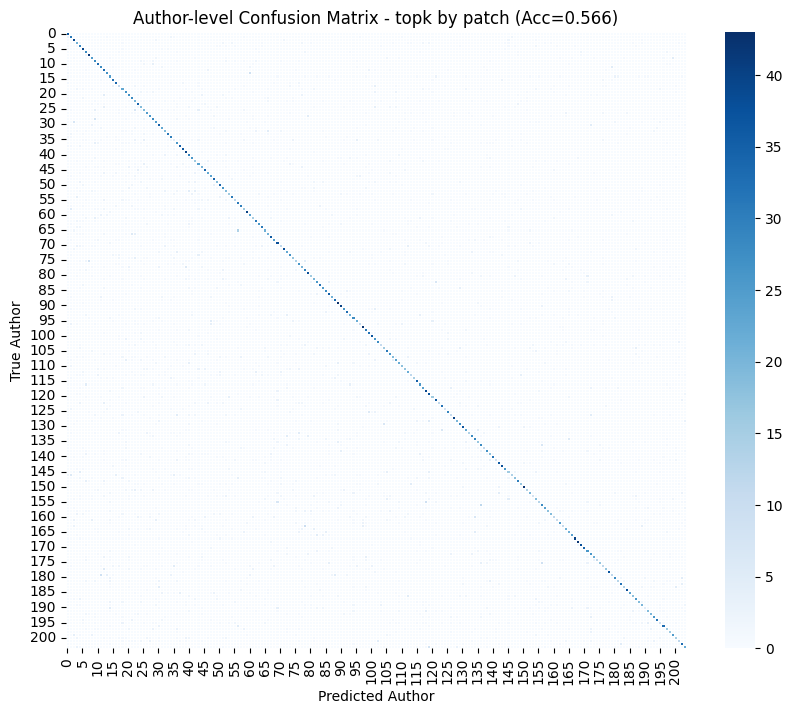

In [65]:
topk_by_patch = topk['patch']
cm_df = build_author_confusion_matrix(
    topk_by_patch.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix - topk by patch")

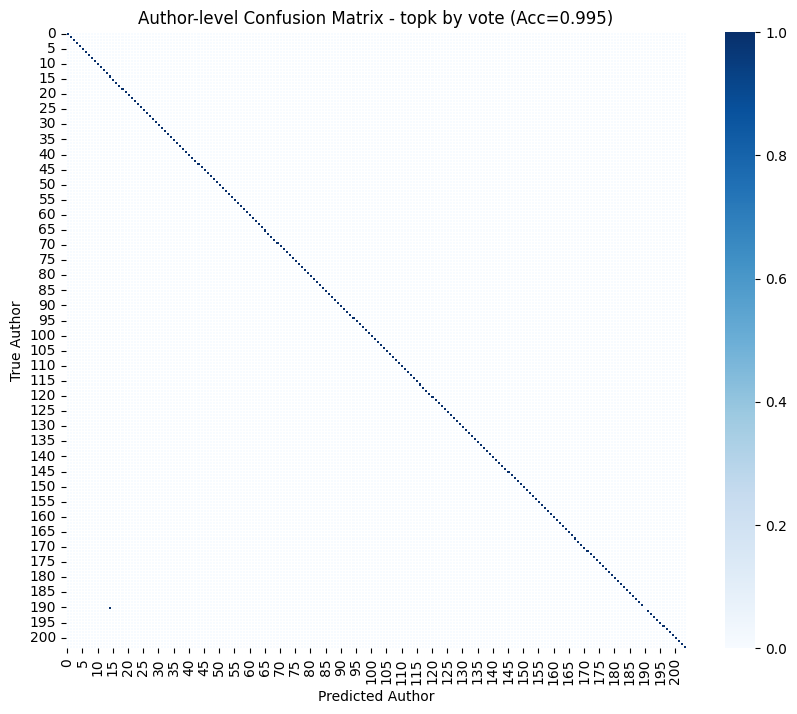

In [66]:
topk_by_vote = topk['vote']
cm_df = build_author_confusion_matrix(
    topk_by_vote.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix - topk by vote")

In [67]:
topk_data = topk_by_vote.data
topk_error_data = topk_data[topk_data['correct'] == False]
topk_error_data[['author', 'author_pred']]

,author,author_pred
190,190,14


In [68]:
viz.plot_centroids([190, 14])

13:30:41 - mobile_test_204_4 - INFO - Estimated DBSCAN eps=0.7377 | clusters=32


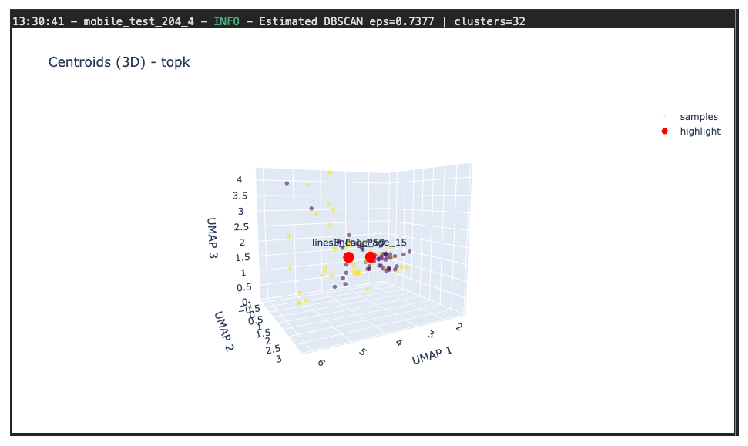

In [88]:
display_output(path="./outputs/embeddings_sample_errors_1.png")

## Unseen Author Evaluation

So far, all evaluations have been performed on authors the model was trained on (**closed-set** evaluation).

This section evaluates the model on **completely unseen authors** — identities never seen during training.

**Why this matters:**
A metric learning model that only works on known identities has limited practical value.
True generalization means the learned embedding space transfers to new identities —
patches from the same unseen author should still cluster together, and patches from different unseen authors should remain apart.

**Setup:**
- Model trained on authors `0–203`
- Evaluated on authors `204–406` (never seen during training)
- No retraining or fine-tuning — same model, same weights

> This is the most demanding test of the system: if vote accuracy remains high on unseen authors, the model has learned a general representation of handwriting style, not a memorization of known identities.


In [69]:
unseen_train, unseen_val, unseen_test = loader.build(
    authors=range(204, 407),
    validation_fraction=config.training.val_ratio,
)

13:33:20 - mobile_test_204_4 - INFO - Total patches selected: 124645
13:33:20 - mobile_test_204_4 - INFO - Train: 93483 | Val: 31162 | Test: 8722
13:33:20 - mobile_test_204_4 - INFO - Avg non_test patches per author: 614.01 | Min: 84 | Max: 982
13:33:20 - mobile_test_204_4 - INFO - Avg test patches per author: 42.97 | Min: 14 | Max: 49
13:33:20 - mobile_test_204_4 - INFO - Image shape: (180, 360)
13:33:20 - mobile_test_204_4 - INFO - Zarr chunk shape: (64, 180, 360)


In [70]:
unseen_test_gen = DataGenerator(
    split=unseen_test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [71]:
display_generator_info(unseen_test_gen)

13:33:41 - mobile_test_204_4 - INFO - Generator: DataGenerator
13:33:41 - mobile_test_204_4 - INFO - Number of samples: 8722
13:33:41 - mobile_test_204_4 - INFO - Batch size: 16
13:33:41 - mobile_test_204_4 - INFO - Steps per epoch: 546
13:33:41 - mobile_test_204_4 - INFO - Shape: (180, 360)
13:33:41 - mobile_test_204_4 - INFO - Number of authors: 203


In [72]:
unseen_test_gen_results = emb_evaluator.evaluate(
    data_generator=unseen_test_gen,
    reducer=UMAPReducer(n_components=3),
)

13:33:52 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Starting evaluation
13:33:52 - mobile_test_204_4 - INFO - Extracting embeddings from the model
13:33:52 - mobile_test_204_4 - INFO - Processing 546 batches to extract embeddings
13:35:19 - mobile_test_204_4 - INFO - Extracted embeddings for 8722 samples
13:35:19 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(8722, 224)
13:35:19 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances
13:35:19 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Reducing dimensionality with UMAP


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



13:35:34 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Evaluating strategies
13:35:34 - mobile_test_204_4 - INFO - Applying strategy pipeline with 4 strategies and 3 aggregators.
13:35:34 - mobile_test_204_4 - INFO - Applying strategy: 1nn
13:35:35 - mobile_test_204_4 - INFO - Applying aggregator: patch
13:35:35 - mobile_test_204_4 - INFO - Applying aggregator: vote
13:35:35 - mobile_test_204_4 - INFO - Applying aggregator: score
13:35:35 - mobile_test_204_4 - INFO - patch acc=0.6434Strategy '1nn' results: , vote acc=1.0000Strategy '1nn' results: , score acc=1.0000
13:35:35 - mobile_test_204_4 - INFO - Applying strategy: mean
13:36:05 - mobile_test_204_4 - INFO - Applying aggregator: patch
13:36:05 - mobile_test_204_4 - INFO - Applying aggregator: vote
13:36:05 - mobile_test_204_4 - INFO - Applying aggregator: score
13:36:05 - mobile_test_204_4 - INFO - patch acc=0.3041Strategy 'mean' results: , vote acc=0.5517Strategy 'mean' results: , score acc=0.5419
13:36:05 - mobile_test_204_4

In [73]:
logger.info(f"Intra distance: {unseen_test_gen_results.intra_distance}")
logger.info(f"Inter distance: {unseen_test_gen_results.inter_distance}")
logger.info(f"Inter/Intra ratio ≈ {unseen_test_gen_results.inter_distance/unseen_test_gen_results.intra_distance}")

for strategy_name, agg_results in unseen_test_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

13:36:58 - mobile_test_204_4 - INFO - Intra distance: 0.3640640377998352
13:36:58 - mobile_test_204_4 - INFO - Inter distance: 0.948944091796875
13:36:58 - mobile_test_204_4 - INFO - Inter/Intra ratio ≈ 2.6065306663513184
13:36:58 - mobile_test_204_4 - INFO - Strategy: 1nn
13:36:58 - mobile_test_204_4 - INFO - Patch accuracy: 0.6434
13:36:58 - mobile_test_204_4 - INFO - Vote accuracy: 1.0000
13:36:58 - mobile_test_204_4 - INFO - Score accuracy: 1.0000
13:36:58 - mobile_test_204_4 - INFO - ----------------------------------------
13:36:58 - mobile_test_204_4 - INFO - Strategy: mean
13:36:58 - mobile_test_204_4 - INFO - Patch accuracy: 0.3041
13:36:58 - mobile_test_204_4 - INFO - Vote accuracy: 0.5517
13:36:58 - mobile_test_204_4 - INFO - Score accuracy: 0.5419
13:36:58 - mobile_test_204_4 - INFO - ----------------------------------------
13:36:58 - mobile_test_204_4 - INFO - Strategy: centroid
13:36:58 - mobile_test_204_4 - INFO - Patch accuracy: 0.3703
13:36:58 - mobile_test_204_4 - IN

## Probabilistic Interpretation of Voting

To explain the near-perfect document-level accuracy, we model the voting mechanism using a binomial distribution.

For the `unseen` setting:

$$
X \sim \text{Binomial}(n = 44, \, p = 0.6434)
$$

$$
\mu = np = 44 \cdot 0.6434 \approx 28.31
$$

$$
\sigma = \sqrt{np(1-p)} = \sqrt{44 \cdot 0.6434 \cdot 0.3566} \approx 3.18
$$

Using a normal approximation with continuity correction:

$$
P(X \ge 22) \approx P\left(Z \ge \frac{21.5 - 28.31}{3.18}\right)
$$

$$
Z \approx -2.14
$$

$$
P(X \ge 22) \approx 0.9838
$$

Thus, under the independence assumption, the probability of obtaining a correct majority remains high even for unseen authors. This is broadly consistent with the observed vote accuracy of 1.0 and score accuracy of 1.0 for the `1nn` strategy.

---

Additionally, the embedding space remains reasonably separable in the unseen setting:

$$
\text{Intra distance} \approx 0.364, \quad
\text{Inter distance} \approx 0.949, \quad
\frac{\text{Inter}}{\text{Intra}} \approx 2.61
$$

This indicates that inter-class distances still dominate intra-class distances, although the margin is weaker than in the MobileNet-based embedding space.

---

However, this analysis assumes independence between patches. In practice, patches extracted from the same document are correlated.

Therefore, the binomial model should be interpreted only as a useful approximation. The observed robustness of vote aggregation is more plausibly explained by the combination of:

- patch-level accuracy above chance and above the majority threshold,
- residual embedding separability,
- and consistent nearest-neighbor structure across patches from the same writer.

In other words, voting remains stable not only because $p > 0.5$, but also because most patches from the same document still tend to be embedded closer to the correct class than to competing classes.

### Unseen Results Summary

The drop in patch accuracy (~5pp) is expected, as the model was not trained on these identities. However, the near-perfect vote accuracy (1.0 for 1NN) indicates that the embedding space generalizes well to unseen authors. While individual patches remain ambiguous, their aggregation yields highly consistent predictions, suggesting that most samples are still embedded closer to the correct class than to competing classes.


In [74]:
unseen_viz = EmbeddingVisualizer(
    report=unseen_test_gen_results,
    logger=logger,
    split=unseen_test,
)
unseen_viz.set_strategy("1nn")

In [75]:
unseen_viz.plot_embeddings()

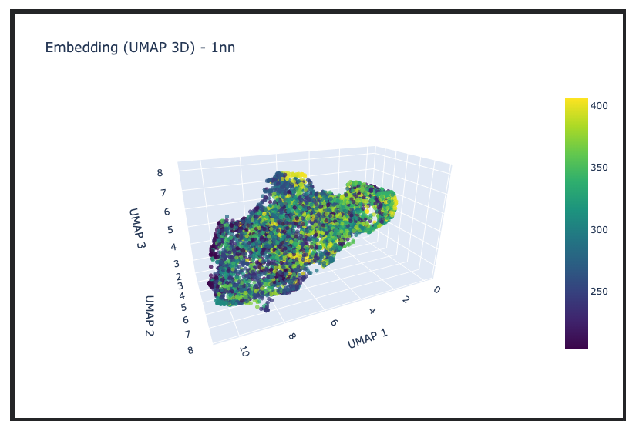

In [89]:
display_output(path="./outputs/unseen_embeddings.png")

In [76]:
unseen_viz.plot_centroids()

13:50:00 - mobile_test_204_4 - INFO - Estimated DBSCAN eps=0.6841 | clusters=26


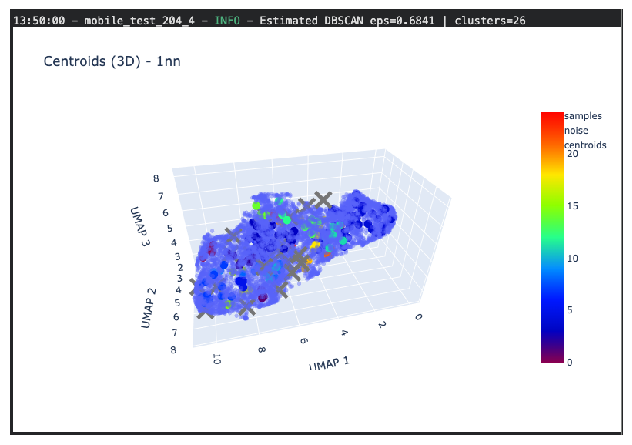

In [90]:
display_output(path="./outputs/unseen_embeddings_centroids.png")

In [77]:
unseen_1nn = unseen_test_gen_results.strategy_results['1nn']

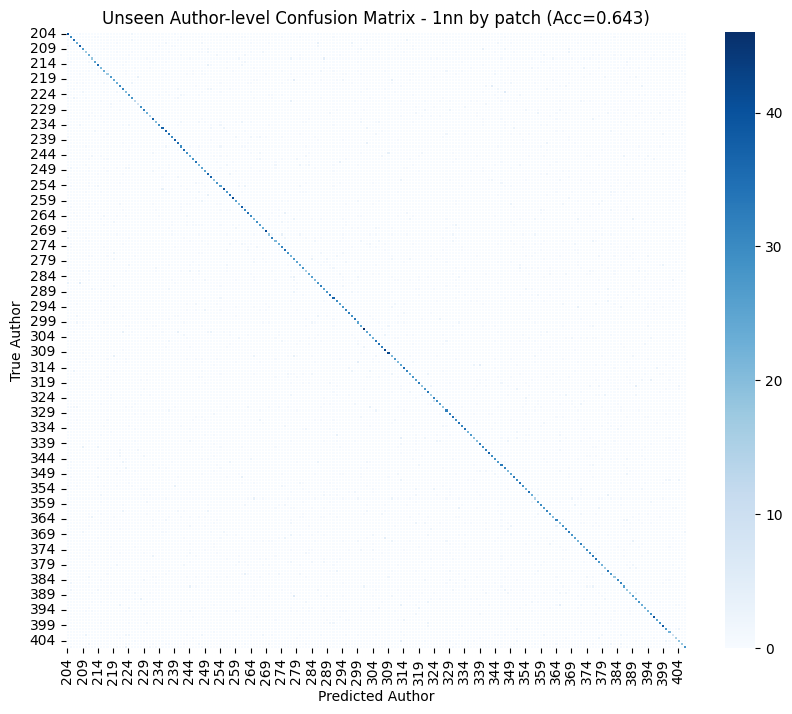

In [78]:
unseen_1nn_by_patch = unseen_1nn['patch']
cm_df = build_author_confusion_matrix(
    unseen_1nn_by_patch.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Unseen Author-level Confusion Matrix - 1nn by patch")

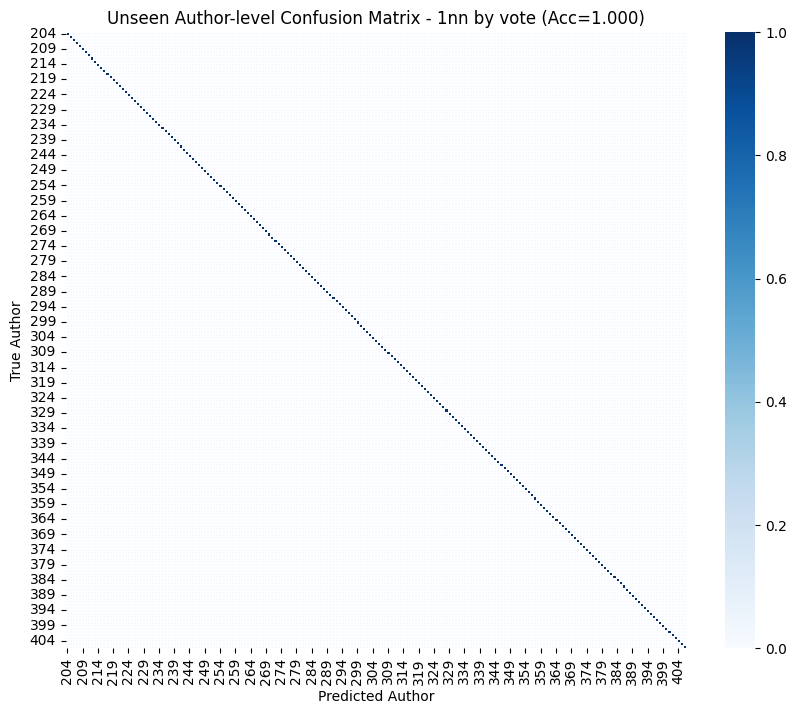

In [79]:
unseen_1nn_by_vote = unseen_1nn['vote']
cm_df = build_author_confusion_matrix(
    unseen_1nn_by_vote.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Unseen Author-level Confusion Matrix - 1nn by vote")

In [80]:
unseen_viz.set_strategy("topk")
unseen_topk = unseen_test_gen_results.strategy_results['topk']

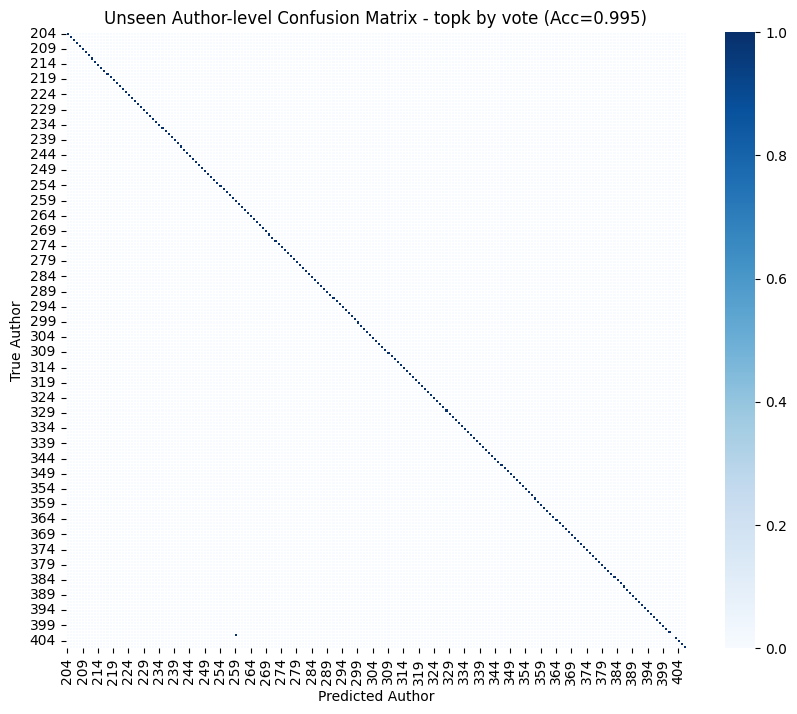

In [81]:
unseen_topk_by_vote = unseen_topk['vote']
cm_df = build_author_confusion_matrix(
    unseen_topk_by_vote.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Unseen Author-level Confusion Matrix - topk by vote")

In [82]:
unseen_viz.plot_centroids([204, 406])

13:52:04 - mobile_test_204_4 - INFO - Estimated DBSCAN eps=0.6841 | clusters=26


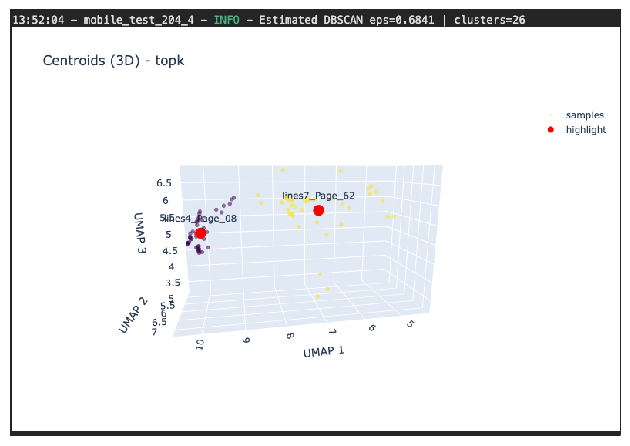

In [91]:
display_output(path="./outputs/unseen_embeddings_sample_1.png")

In [83]:
topk_data = unseen_topk_by_vote.data
topk_error_data = topk_data[topk_data['correct'] == False]
topk_error_data[['author', 'author_pred']]

,author,author_pred
198,402,259


### Error Analysis — Unseen Authors

The following pairs are the authors misclassified by the centroid strategy.
Each pair is visualized in UMAP space to understand why the model confuses them.

These errors are particularly informative in the unseen setting:
since the model never saw these authors, confusions reveal genuine similarity
in handwriting style rather than artifacts of training.

In [84]:
unseen_viz.plot_centroids([402, 259])

13:53:39 - mobile_test_204_4 - INFO - Estimated DBSCAN eps=0.6841 | clusters=26


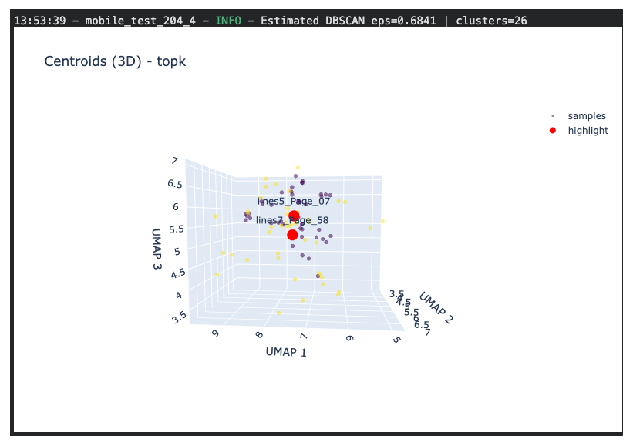

In [92]:
display_output(path="./outputs/unseen_embeddings_sample_errors_1.png")